# This notebook explains how to extract the data from the predictor raster variables to the point layer with landslide presence/absence points.


##  Libraries used in this notebook

### 1\. Geospatial and Data Core

 * **`pyspatialml` (`Raster`):** **The Spatial Image Handler.** A specialized object for working with satellite images or elevation grids (rasters) that keeps track of their geographic location (coordinates).
 * **`geopandas`:** **The Map Data Manager.** Extends standard data tables (`pandas`) to handle geographic features like countries, roads, or sampled points (vector data).
 * **`pandas` (`pd`):** **The Data Table.** The primary tool for creating, viewing, and modifying structured, labeled data (like spreadsheets or CSVs).
 * **`numpy` (`np`):** **The Math Engine.** Used for lightning-fast numerical operations, especially when dealing with large grids of numbers (like the pixels in an image).
 * **`rasterio.plot`:** **Quick Raster Plotting.** A utility specifically for drawing and visualizing the content of a geospatial image file.

### 2\. Visualization and Style

 * **`matplotlib.pyplot` (`plt`):** **The Plotting Canvas.** The main library for creating and customizing all types of charts, graphs, and maps.
 * **`matplotlib` (`mpl`):** **The Plot Stylist.** Used to change global settings and default looks for all the plots you create.
 * **`seaborn` (`sn`):** **Statistical Graphics.** A library that makes drawing complex statistical charts (like distributions or heatmaps) much simpler and more attractive.

### 3\. System Utilities

 * **`os`:** **File and System Access.** Used to interact with your computer's operating system, such as navigating folders or checking if a file exists.

In [1]:
pip install pyspatialml #install the Python package named pyspatialml using the pip tool. Only need to run this once during the entire tutorial

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pyspatialml import Raster # Library for working with geospatial rasters (bands, stacks)
import os # Library for interacting with the operating system (e.g., changing directories)
import matplotlib.pyplot as plt # Library for creating static, interactive, and animated visualizations (plotting)
import matplotlib as mpl # Matplotlib library for setting global plot styles
import geopandas # Library for working with geospatial vector data (shapefiles)
import pandas as pd # Library for data manipulation and analysis (DataFrames)
import seaborn as sn # Library for statistical data visualization (not explicitly used here)
import rasterio.plot # Utility for plotting raster data
import numpy as np # Library for efficient numerical operations and array handling

Setting up the directiry path

In [2]:
os.chdir(r'/workspace/VY') # Set the current working directory to the 'VY' study area folder

Choosing all the predictors

In [3]:
# This list defines all the environmental factors (rasters) that will be used to predict landslide susceptibility.
# This set of predictors will be loaded and stacked together.
predictors = ['elevation.tif', 'lulc.tif', 'ndvi.tif', 'ndwi.tif', 'river.tif', 'road.tif', 'lithology.tif', 'lithology_boundary.tif', 'fault.tif', 'twi.tif', 'spi.tif', 'tri.tif','roughness.tif', 'slope.tif', 'aspect.tif', 'profile.tif','planform.tif']

Making a raster stack of all the predictors. The predictors have the same extent, projection and resolution


In [4]:
print(f"Number of predictor: {len(predictors)}") # Print the total count of predictor variables

Number of predictor: 17


In [5]:
stack = Raster(predictors) # Create a Raster stack object from the list of GeoTIFF files.
                           # A raster stack is like a multi-band image where each band is an environmental variable.

Checking the bands in our stack


In [6]:
# Display the names of the layers (bands) in the created raster stack.
stack.names # All predictor files must have the same extend, the stack result will list all  redictor files in the stack

dict_keys(['elevation', 'lulc', 'ndvi', 'ndwi', 'river', 'road', 'lithology', 'lithology_boundary', 'fault', 'twi', 'spi', 'tri', 'roughness', 'slope', 'aspect', 'profile', 'planform'])

Reading the shapefile with landslide (centroids)/nonlandslide (randomly created) points and showing the first five rows

In [7]:
training_pt = geopandas.read_file(r'/workspace/shape_files/VY/sample_points.shp') # Load the vector file (shapefile) containing the landslide presence/absence points.
training_pt.head(5) # Display the first five rows of the geopandas DataFrame to inspect the point data.

,Landslide,ID,geometry
0,1,NaN,POINT Z (472413.688 2416624.130 34.600)
1,1,NaN,POINT Z (464244.069 2418792.248 73.200)
2,1,NaN,POINT Z (467200.796 2424526.948 130.700)
3,1,NaN,POINT Z (452646.998 2434559.314 63.400)
4,1,NaN,POINT Z (466629.020 2420779.079 60.700)


Plotting the landslide/non-landslide points on the background of the DEM


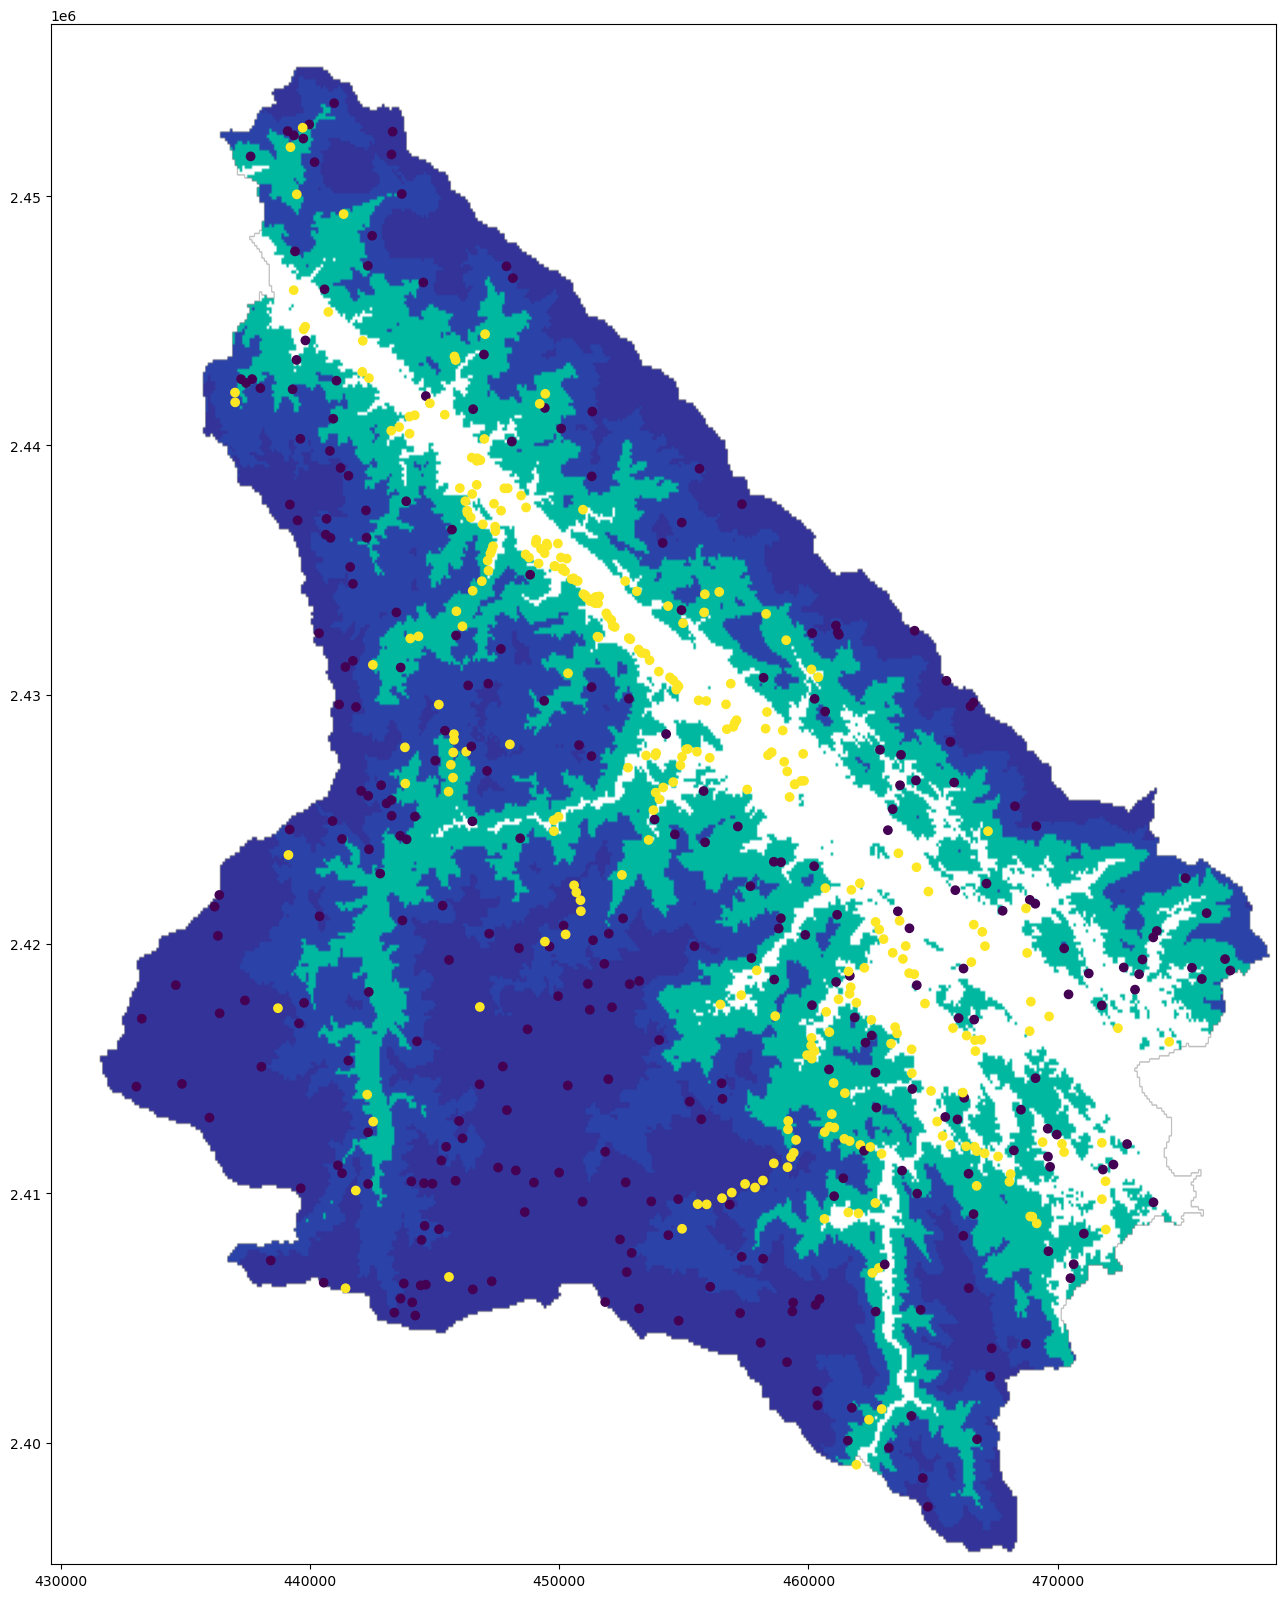

In [13]:
fig, ax = plt.subplots(figsize=(20, 20)) # Create a large figure and axes for plotting
stack.elevation.plot(ax=ax, cmap='terrain') # Plot the elevation band from the stack as the base map, using a 'terrain' color scheme, there are different color schemes to use
training_pt.plot(column="Landslide", ax=ax) # Overlay the sample points, coloring them based on the "Landslide" column (presence/absence).
plt.show() # Display the plot.

Extracting the predictor features from the raster stack to our points


In [14]:
df_points = stack.extract_vector(training_pt) # Core step: For every point in training_pt, extract the value from ALL layers in the raster stack.
                                            # The result is a DataFrame where each row is a point and each column is a predictor value.

Showing the first five rows


In [15]:
df_points.head(5) # Display the result of the extraction—the points now have associated predictor values.

,,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,geometry
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,,
0,0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.32,0.37,1.63,1.57,1.06,1.00,0.83,POINT (472413.688 2416624.130)
1,1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,2.72,0.15,1.26,3.34,0.88,0.98,1.12,POINT (464244.069 2418792.248)
2,2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,1.32,0.15,0.61,1.57,0.69,0.98,1.12,POINT (467200.796 2424526.948)
3,3,3.77,NaN,2.39,1.86,1.26,3.57,0.41,0.13,0.78,1.13,1.09,0.58,0.37,1.63,1.57,1.06,1.06,1.12,POINT (452646.998 2434559.314)
4,4,3.77,2.88,1.07,1.86,1.41,3.57,3.22,0.13,0.78,1.13,1.09,0.58,0.37,1.63,0.39,1.25,0.98,1.12,POINT (466629.020 2420779.079)


Merging the data frame back with the class

In [16]:
# Merge the extracted predictor values with the original landslide/non-landslide label (the "class").
df_points = df_points.merge(
    right=training_pt.loc[:, ["Landslide"]], # The column to merge (the class label)
    left_on="geometry_idx", # Key column from the extracted data (index of the point)
    right_on="index", # Key column from the original point data (index)
    right_index=True # Use the index of the right DataFrame as the merge key
)

In [17]:
df_points.head(5) # Display the final DataFrame, which now contains all predictor features AND the 'Landslide' class label.

,,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,geometry,Landslide
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,,,
0,0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.32,0.37,1.63,1.57,1.06,1.00,0.83,POINT (472413.688 2416624.130),1
1,1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,2.72,0.15,1.26,3.34,0.88,0.98,1.12,POINT (464244.069 2418792.248),1
2,2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,1.32,0.15,0.61,1.57,0.69,0.98,1.12,POINT (467200.796 2424526.948),1
3,3,3.77,NaN,2.39,1.86,1.26,3.57,0.41,0.13,0.78,1.13,1.09,0.58,0.37,1.63,1.57,1.06,1.06,1.12,POINT (452646.998 2434559.314),1
4,4,3.77,2.88,1.07,1.86,1.41,3.57,3.22,0.13,0.78,1.13,1.09,0.58,0.37,1.63,0.39,1.25,0.98,1.12,POINT (466629.020 2420779.079),1


Dropping the "Geometry" column


In [18]:
df_points.to_csv('sample_points.csv', index = False) # Temporarily save the full DataFrame to 'sample_points.csv' (before dropping geometry).

In [19]:
data= df_points.drop(columns=['geometry']) # Create a new DataFrame 'data' by dropping the 'geometry' column (it's not needed for ML training).

Decribing the data

In [20]:
data.describe() # Display summary statistics (count, mean, min, max, quartiles) for all columns in the final ML dataset.

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,Landslide
count,615.000000,542.000000,615.000000,615.000000,615.000000,615.000000,616.000000,615.000000,615.000000,615.000000,613.000000,615.000000,615.000000,615.000000,615.000000,606.000000,615.000000,615.000000,616.000000
mean,1.670081,1.518118,1.170683,1.106959,1.056130,1.751382,0.942338,14.201350,1.046894,1.010976,1.044160,1.248553,0.264927,1.260358,1.635724,1.015726,1.002634,1.013577,0.500000
std,1.594501,0.979008,0.703801,0.535247,0.340658,1.471057,1.001584,6.332952,0.359511,0.183076,0.207852,0.806083,0.120770,0.465309,1.089997,0.186608,0.031923,0.118584,0.500406
min,0.160000,0.560000,0.200000,0.460000,0.140000,0.060000,0.090000,0.130000,0.780000,0.630000,0.310000,0.260000,0.110000,0.610000,0.320000,0.690000,0.980000,0.830000,0.000000
25%,0.250000,0.560000,1.070000,0.460000,1.010000,0.060000,0.410000,17.250000,0.780000,0.920000,1.090000,0.580000,0.150000,0.610000,0.390000,0.880000,0.980000,0.830000,0.000000
50%,0.930000,1.630000,1.070000,1.020000,1.010000,1.890000,0.520000,17.250000,0.780000,1.130000,1.090000,1.320000,0.370000,1.630000,1.570000,1.060000,0.980000,1.060000,0.500000
75%,3.770000,1.630000,1.070000,1.860000,1.260000,3.570000,0.770000,17.250000,1.320000,1.130000,1.090000,1.320000,0.370000,1.630000,1.570000,1.120000,1.000000,1.120000,1.000000
max,3.770000,4.470000,2.390000,1.860000,1.410000,3.570000,3.220000,17.250000,1.690000,1.130000,1.140000,2.720000,0.370000,2.020000,3.340000,1.250000,1.060000,1.120000,1.000000


Cheking the data types in the columns and missing values


In [21]:
data.info() # Display a concise summary, including the data type of each column and a check for any remaining missing (non-null) values.

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 616 entries, (0, 0) to (615, 615)
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   elevation           615 non-null    float64
 1   lulc                542 non-null    float64
 2   ndvi                615 non-null    float64
 3   ndwi                615 non-null    float64
 4   river               615 non-null    float64
 5   road                615 non-null    float64
 6   lithology           616 non-null    float64
 7   lithology_boundary  615 non-null    float64
 8   fault               615 non-null    float64
 9   twi                 615 non-null    float64
 10  spi                 613 non-null    float64
 11  tri                 615 non-null    float64
 12  tpi                 615 non-null    float64
 13  roughness           615 non-null    float64
 14  slope               615 non-null    float64
 15  aspect              606 non-null    float64
 

Saving data as a .csv file for later use

In [23]:
data.to_csv('sample_points.csv', index = False) # Save the final, clean, machine-learning ready dataset as a CSV file for the VY area.

End.